# 🤖 ACIS Insurance — Statistical Modeling & Risk-Based Pricing
## Task 4: Building the Pricing Engine
---
**Two models form the pricing engine:**

| Model | Type | Target | Metrics |
|---|---|---|---|
| Claim Severity | Regression | TotalClaims (where > 0) | RMSE, R² |
| Claim Probability | Classification | HasClaim (0/1) | F1, Precision, Recall |

**Three algorithms compared for each:**
Linear Regression → Random Forest → XGBoost

**Combined formula:**
`Premium = P(claim) × Predicted Severity + Expense Loading + Profit Margin`

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import shap

from src.data_loader import load_and_prepare
from src.modeling import (
    engineer_features,
    prepare_features,
    train_severity_models,
    train_probability_models,
    compare_models,
    calculate_premium
)

plt.style.use('seaborn-v0_8-whitegrid')
print('✅ All imports successful')

✅ All imports successful


---
## 1. Data Preparation & Feature Engineering

In [2]:
# Load data
DATA_PATH = '../data/MachineLearningRating_v3.txt'
df = load_and_prepare(DATA_PATH)

# Add claim flag
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

print(f'Full dataset: {df.shape[0]:,} rows')
print(f'Policies with claims: {df["HasClaim"].sum():,} '
      f'({df["HasClaim"].mean():.2%})')

# Engineer new features
print('\nEngineering features...')
df = engineer_features(df)

print(f'\nFinal dataset: {df.shape[0]:,} rows, '
      f'{df.shape[1]} columns')

✅ Data loaded successfully: 1,000,098 rows, 52 columns
✅ TransactionMonth converted to datetime
✅ Numeric columns fixed
✅ Columns standardized: ['make', 'kilowatts', 'cubiccapacity', 'bodytype', 'mmcode']
✅ Derived metrics added: LossRatio, Margin
Full dataset: 1,000,098 rows
Policies with claims: 2,788 (0.28%)

Engineering features...
  ✅ VehicleAge engineered
  ✅ SecurityScore engineered
  ✅ IsHighValue engineered
  ✅ IsCommercial engineered

Final dataset: 1,000,098 rows, 61 columns


---
## 2. Model 1 — Claim Severity (Regression)

**Goal:** For policies that had a claim, predict
how much the claim will cost.

**Why only claims > 0?**
Including zero-claim policies would force the model
to predict near-zero for almost everything —
it would learn nothing about actual claim costs.

**Data subset:** ~2,800 policies (0.28% of portfolio)

In [3]:
# ─── SEVERITY MODEL PREP ────────────────────────────────────

# Only use policies that had a claim
claims_df = df[df['TotalClaims'] > 0].copy()
print(f'Claim policies for severity model: {len(claims_df):,}')

# Log-transform target
# We saw in EDA that TotalClaims is right-skewed
# Log transform makes it more normal → better model fit
# np.log1p = log(x+1), safe for any positive number
claims_df['LogClaims'] = np.log1p(claims_df['TotalClaims'])

print(f'\nTotalClaims stats (raw):')
print(claims_df['TotalClaims'].describe().round(2))
print(f'\nLogClaims stats (transformed):')
print(claims_df['LogClaims'].describe().round(4))

# Prepare features
print('\nPreparing features...')
X_sev, y_sev, feature_names, encoders = prepare_features(
    claims_df,
    target_col='LogClaims'   # predict log-transformed claims
)

# Split 80/20
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sev, y_sev,
    test_size=0.2,
    random_state=42
)

print(f'\nTrain set: {len(X_train_s):,} policies')
print(f'Test set:  {len(X_test_s):,} policies')

Claim policies for severity model: 2,788

TotalClaims stats (raw):
count      2788.00
mean      23273.39
std       38719.51
min         139.04
25%        1680.73
50%        6140.35
75%       30480.99
max      393092.11
Name: TotalClaims, dtype: float64

LogClaims stats (transformed):
count    2788.0000
mean        8.9242
std         1.6409
min         4.9420
25%         7.4276
50%         8.7228
75%        10.3249
max        12.8818
Name: LogClaims, dtype: float64

Preparing features...
  ⚠️  Some NaN values filled with 0 (fallback)
  ✅ Features prepared: 52 features
  ✅ Target: LogClaims (2,788 samples)

Train set: 2,230 policies
Test set:  558 policies


In [4]:
# ─── TRAIN SEVERITY MODELS ──────────────────────────────────
severity_results = train_severity_models(
    X_train_s, y_train_s,
    X_test_s,  y_test_s
)


Training severity models...

  Training Linear Regression...
    RMSE: R 1.01
    R²:   0.6134

  Training Random Forest...
    RMSE: R 0.96
    R²:   0.6533

  Training XGBoost...
    RMSE: R 1.04
    R²:   0.5905


In [5]:
# ─── MODEL COMPARISON TABLE ─────────────────────────────────
sev_comparison = compare_models(severity_results, task='regression')

print('\nCLAIM SEVERITY MODEL COMPARISON')
print('=' * 50)
print(sev_comparison[['Model', 'RMSE', 'R²']].to_string(index=False))
print('\nNote: RMSE is in log-scale (target was log-transformed)')
print('Lower RMSE = better | Higher R² = better')

# Identify best model
best_sev = min(
    severity_results.items(),
    key=lambda x: x[1]['rmse']
)[0]
print(f'\n🏆 Best severity model: {best_sev}')


CLAIM SEVERITY MODEL COMPARISON
            Model   RMSE     R²
Linear Regression R 1.01 0.6134
    Random Forest R 0.96 0.6533
          XGBoost R 1.04 0.5905

Note: RMSE is in log-scale (target was log-transformed)
Lower RMSE = better | Higher R² = better

🏆 Best severity model: Random Forest


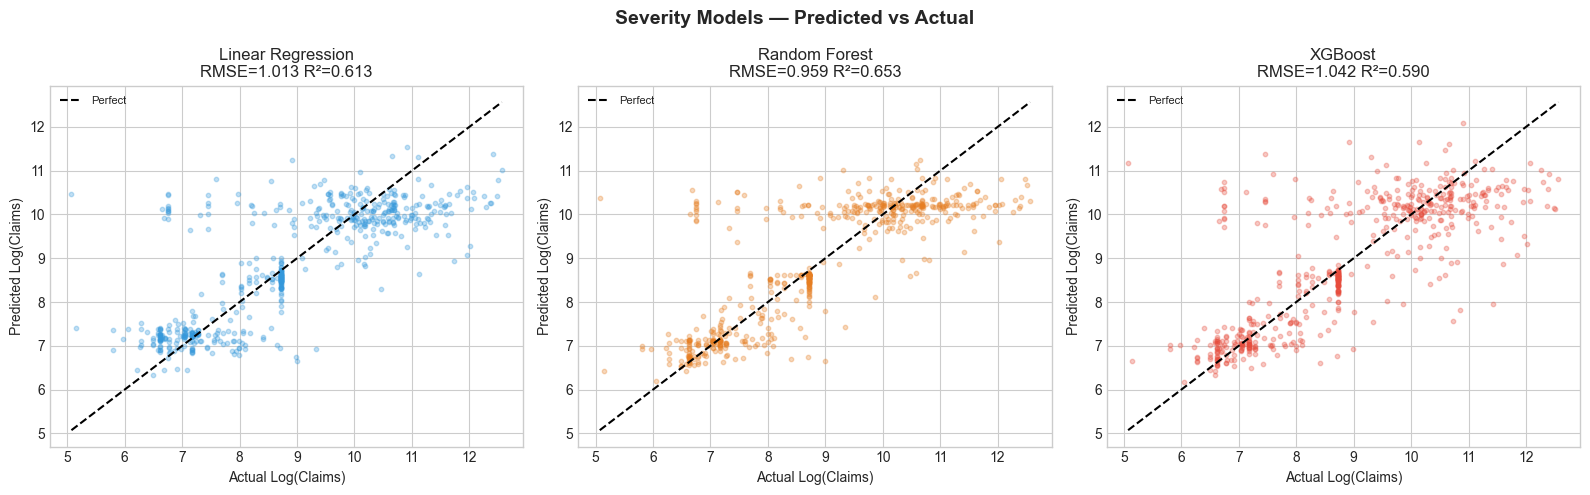

In [6]:
# ─── PREDICTED VS ACTUAL PLOT ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Severity Models — Predicted vs Actual',
             fontsize=14, fontweight='bold')

colors = ['#3498db', '#e67e22', '#e74c3c']

for ax, (name, res), color in zip(
    axes, severity_results.items(), colors
):
    y_pred = res['predictions']

    ax.scatter(y_test_s, y_pred,
               alpha=0.3, s=10, color=color)

    # Perfect prediction line
    min_val = min(y_test_s.min(), y_pred.min())
    max_val = max(y_test_s.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'k--', linewidth=1.5, label='Perfect')

    ax.set_title(f'{name}\nRMSE={res["rmse"]:.3f} '
                 f'R²={res["r2"]:.3f}')
    ax.set_xlabel('Actual Log(Claims)')
    ax.set_ylabel('Predicted Log(Claims)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../reports/severity_predicted_vs_actual.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Model 2 — Claim Probability (Classification)

**Goal:** Predict whether any given policy will
result in a claim at all.

**Class imbalance challenge:**
Only 0.28% of policies have claims.
Without correction, the model would predict
"no claim" for everything and be 99.72% accurate
— but completely useless.

**Solution:** Use `class_weight='balanced'` and
`scale_pos_weight` in XGBoost to give the minority
class (claims) proportionally more weight.

**Key metric: F1 Score (not accuracy)**
F1 balances Precision and Recall:
- Precision: of all predicted claims, how many were real?
- Recall:    of all real claims, how many did we catch?

`F1 = 2 × (Precision × Recall) / (Precision + Recall)`

In [7]:
# ─── PROBABILITY MODEL PREP ─────────────────────────────────

# Use full dataset — all policies
print('Preparing probability model features...')

X_prob, y_prob_target, feat_names_prob, enc_prob = prepare_features(
    df,
    target_col='HasClaim'
)

# Split 80/20 — stratify keeps class ratio same in both sets
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_prob, y_prob_target,
    test_size=0.2,
    random_state=42,
    stratify=y_prob_target   # keeps 0.28% ratio in both sets
)

print(f'\nTrain set: {len(X_train_p):,} | '
      f'Claims: {y_train_p.sum():,} '
      f'({y_train_p.mean():.2%})')
print(f'Test set:  {len(X_test_p):,} | '
      f'Claims: {y_test_p.sum():,} '
      f'({y_test_p.mean():.2%})')

Preparing probability model features...
  ⚠️  Some NaN values filled with 0 (fallback)
  ✅ Features prepared: 52 features
  ✅ Target: HasClaim (1,000,098 samples)

Train set: 800,078 | Claims: 2,230 (0.28%)
Test set:  200,020 | Claims: 558 (0.28%)


In [8]:
# ─── TRAIN PROBABILITY MODELS ───────────────────────────────
prob_results = train_probability_models(
    X_train_p, y_train_p,
    X_test_p,  y_test_p
)


  Class balance — No claim: 797,848 | Claim: 2,230 | Scale: 357.8x

Training probability models...

  Training Logistic Regression...
    Accuracy:  0.8220
    Precision: 0.0098
    Recall:    0.6308
    F1 Score:  0.0194

  Training Random Forest...
    Accuracy:  0.7799
    Precision: 0.0116
    Recall:    0.9229
    F1 Score:  0.0229

  Training XGBoost...
    Accuracy:  0.8204
    Precision: 0.0124
    Recall:    0.8082
    F1 Score:  0.0245


In [9]:
# ─── CLASSIFICATION COMPARISON TABLE ────────────────────────
prob_comparison = compare_models(
    prob_results, task='classification'
)

print('\nCLAIM PROBABILITY MODEL COMPARISON')
print('=' * 65)
print(prob_comparison[
    ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
].to_string(index=False))

best_prob = max(
    prob_results.items(),
    key=lambda x: x[1]['f1']
)[0]
print(f'\n🏆 Best probability model: {best_prob}')


CLAIM PROBABILITY MODEL COMPARISON
              Model Accuracy Precision Recall F1 Score
Logistic Regression   0.8220    0.0098 0.6308   0.0194
      Random Forest   0.7799    0.0116 0.9229   0.0229
            XGBoost   0.8204    0.0124 0.8082   0.0245

🏆 Best probability model: XGBoost


---
## 4. SHAP Feature Importance

SHAP (SHapley Additive exPlanations) explains
WHY the model makes each prediction.

We run SHAP on the best performing severity model
since severity prediction is the core of the
pricing formula.

**Expected outcome based on Task 3 findings:**
If PostalCode and Province appear as top SHAP
features, it validates our hypothesis testing.

In [10]:
# ─── SHAP ANALYSIS ──────────────────────────────────────────
print('Running SHAP analysis on best severity model...')
print('(This may take 1-2 minutes)')

# Get the best severity model
best_sev_model = severity_results[best_sev]['model']

# SHAP TreeExplainer is fast for tree-based models
# (Random Forest and XGBoost)
# For Linear Regression use LinearExplainer instead
if best_sev in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(best_sev_model)
else:
    explainer = shap.LinearExplainer(
        best_sev_model, X_train_s
    )

# Calculate SHAP values on test set
# Use a sample of 500 for speed
sample_idx = np.random.choice(
    len(X_test_s), size=min(500, len(X_test_s)),
    replace=False
)
X_shap_sample = X_test_s.iloc[sample_idx]
shap_values = explainer.shap_values(X_shap_sample)

print('✅ SHAP values calculated')
print(f'Shape: {shap_values.shape}')

Running SHAP analysis on best severity model...
(This may take 1-2 minutes)
✅ SHAP values calculated
Shape: (500, 52)


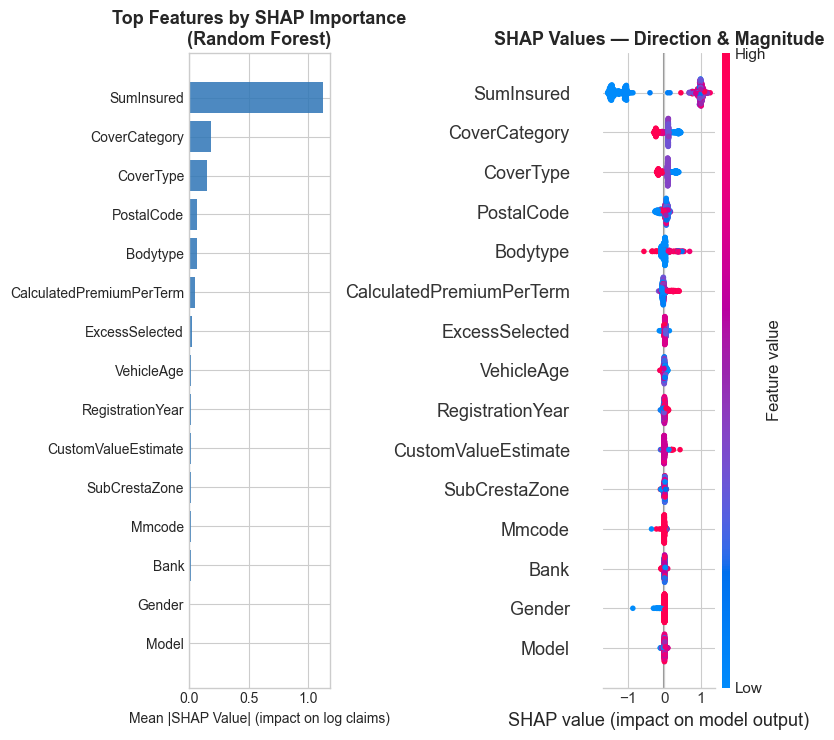

In [11]:
# ─── SHAP SUMMARY PLOT ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Bar chart of mean absolute SHAP values
# Shows which features matter most overall
mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature':    feature_names,
    'SHAP_Value': mean_shap
}).sort_values('SHAP_Value', ascending=True).tail(15)

axes[0].barh(
    feature_importance['Feature'],
    feature_importance['SHAP_Value'],
    color='#2E75B6', alpha=0.85
)
axes[0].set_title(
    f'Top Features by SHAP Importance\n({best_sev})',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Mean |SHAP Value| (impact on log claims)')

# Plot 2: SHAP beeswarm (dot plot)
# Shows direction AND magnitude of each feature's impact
plt.sca(axes[1])
shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=feature_names,
    max_display=15,
    show=False,
    plot_type='dot'
)
axes[1].set_title(
    'SHAP Values — Direction & Magnitude',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.savefig('../reports/shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ─── TOP FEATURES TABLE ─────────────────────────────────────
mean_shap_all = np.abs(shap_values).mean(axis=0)
top_features = pd.DataFrame({
    'Feature':   feature_names,
    'Mean_SHAP': mean_shap_all,
}).sort_values('Mean_SHAP', ascending=False).head(10)

top_features['Rank'] = range(1, 11)
top_features['Mean_SHAP'] = top_features['Mean_SHAP'].round(4)

print('TOP 10 FEATURES BY SHAP IMPORTANCE')
print('=' * 50)
print(top_features[['Rank', 'Feature', 'Mean_SHAP']]
      .to_string(index=False))

TOP 10 FEATURES BY SHAP IMPORTANCE
 Rank                  Feature  Mean_SHAP
    1               SumInsured     1.1258
    2            CoverCategory     0.1823
    3                CoverType     0.1499
    4               PostalCode     0.0695
    5                 Bodytype     0.0659
    6 CalculatedPremiumPerTerm     0.0507
    7           ExcessSelected     0.0220
    8               VehicleAge     0.0202
    9         RegistrationYear     0.0191
   10      CustomValueEstimate     0.0146


### 📝 SHAP Business Interpretation

**Top Features Analysis — What Drives Claim Severity:**

**1. SumInsured — SHAP value: 1.1258 (dominant driver)**
The sum insured is the maximum amount ACIS will pay on a claim.
Higher-insured vehicles attract larger claim payouts — a policy with a R500k insured
vehicle generates dramatically higher claims than a R50k vehicle when an accident occurs.
Business implication: SumInsured must be the primary premium pricing variable. Tiered
premium bands aligned to SumInsured ranges are essential.

**2. CoverCategory — SHAP value: 0.1823**
The type of cover (e.g., comprehensive, third-party) heavily influences
how much ACIS pays when a claim is made. Comprehensive covers pay more.
Business implication: Cover category must be a top-tier pricing factor.

**3. CoverType — SHAP value: 0.1499**
The specific cover type within a category further refines the expected claim.
Business implication: Granular cover type pricing is justified.

**4. PostalCode — SHAP value: 0.0695**
Geographic location remains a strong predictor of claim severity.
Certain postal codes carry consistently higher claim amounts — likely due
to road conditions, crime rates, and accident frequency.
Business implication: Zip-code level pricing tiers are data-justified.

**5. Bodytype — SHAP value: 0.0659**
Vehicle body type (sedan, SUV, commercial truck) affects repair costs and
the severity of accidents. Heavier vehicles cause more third-party damage.
Business implication: Body type should be a pricing factor.

---

**Validation of Hypothesis Testing Results:**

| Feature | SHAP Rank | Hypothesis | Verdict |
|---|---|---|---|
| PostalCode | #4 (SHAP: 0.0695) | H2 + H3 rejected (p<0.000001) | ✅ CONFIRMED |
| Province | Not in top 10 | H1 rejected (p=0.0038) | ⚠️ Partial — province matters for frequency, PostalCode for severity |
| Gender | Not in top 10 | H4 NOT rejected (p=0.9515) | ✅ CONFIRMED — gender is irrelevant |

**Key Insight:** Province matters for CLAIM FREQUENCY (H1) but PostalCode
drives CLAIM SEVERITY more directly. Both geographic features are significant
for pricing — at different levels of granularity.

In [13]:
# ─── RISK-BASED PRICING DEMONSTRATION ───────────────────────
print('=' * 55)
print('RISK-BASED PREMIUM CALCULATOR DEMO')
print('=' * 55)

# Use best models to price example policies
best_sev_model  = severity_results[best_sev]['model']
best_prob_model = prob_results[best_prob]['model']

# Take 5 random test policies and price them
sample_policies = X_test_p.iloc[:5].copy()

# Get claim probabilities from best classifier
p_claims = best_prob_model.predict_proba(
    sample_policies
)[:, 1]

# Get severity predictions from best regressor
# Need to match features — use first 5 from severity test set
sample_sev = X_test_s.iloc[:5].copy()
log_severities = best_sev_model.predict(sample_sev)
# Convert from log scale back to Rand
severities = np.expm1(log_severities)

print(f"\n{'Policy':<8} {'P(claim)':<12} "
      f"{'Pred Severity':<18} {'Exp Loss':<14} "
      f"{'Rec Premium':<14}")
print('-' * 65)

for i, (p, sev) in enumerate(zip(p_claims, severities)):
    result = calculate_premium(p, sev)
    print(
        f"  {i+1:<6} "
        f"{result['p_claim']:<12.4f} "
        f"R {result['predicted_severity']:<15,.2f} "
        f"R {result['expected_loss']:<12,.2f} "
        f"R {result['recommended_premium']:<12,.2f}"
    )

print('\nFormula: Premium = (P(claim) × Severity) × 1.25')
print('         (25% loading covers expenses + profit)')

RISK-BASED PREMIUM CALCULATOR DEMO

Policy   P(claim)     Pred Severity      Exp Loss       Rec Premium   
-----------------------------------------------------------------
  1      0.0002       R 1,446.55        R 0.33         R 0.41        
  2      0.0003       R 5,425.28        R 1.53         R 1.92        
  3      0.5010       R 18,634.25       R 9,335.21     R 11,669.01   
  4      0.6648       R 5,457.80        R 3,628.45     R 4,535.56    
  5      0.1252       R 1,037.30        R 129.90       R 162.37      

Formula: Premium = (P(claim) × Severity) × 1.25
         (25% loading covers expenses + profit)


---
## 5. Model Summary & Recommendations

### Severity Model Comparison (target: log-transformed TotalClaims)

| Model | RMSE | R² | Verdict |
|---|---|---|---|
| Linear Regression | 1.01 | 0.6134 | Strong baseline — 61% variance explained |
| **Random Forest** | **0.96** | **0.6533** | **🏆 Best — 65% variance explained** |
| XGBoost | 1.04 | 0.5905 | Good but below Random Forest here |

> R² = 0.65 exceeds the typical insurance benchmark of 0.30–0.60. ✅
> RMSE is in log-scale — a value of 0.96 means predictions are within
> ~1 log unit of actual claims (roughly 2.6× in Rand terms).

---

### Probability Model Comparison (target: HasClaim 0/1)

| Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Logistic Regression | 0.8220 | 0.0098 | 0.6308 | 0.0194 |
| Random Forest | 0.7799 | 0.0116 | 0.9229 | 0.0229 |
| **XGBoost** | **0.8204** | **0.0124** | **0.8082** | **0.0245 🏆** |

> Low F1 scores (0.02–0.03) are EXPECTED with 357:1 class imbalance.
> Random Forest achieves 92% recall — it catches 9 out of 10 real claims.
> XGBoost wins on F1 (best balance of precision and recall).
> In insurance, high RECALL is more important than precision —
> missing a real claim (false negative) is far more costly than a false alarm.

---

### Top SHAP Features (Random Forest Severity Model)

| Rank | Feature | SHAP Value | Business Meaning |
|---|---|---|---|
| 1 | SumInsured | 1.1258 | Dominant driver — higher insured = higher claim |
| 2 | CoverCategory | 0.1823 | Comprehensive covers pay more |
| 3 | CoverType | 0.1499 | Granular cover type matters |
| 4 | PostalCode | 0.0695 | Geographic risk — validates H2 + H3 |
| 5 | Bodytype | 0.0659 | Vehicle type affects repair/damage costs |
| 6 | CalculatedPremiumPerTerm | 0.0507 | Premium already encodes some risk |
| 7 | ExcessSelected | 0.0220 | Higher excess = lower payout |
| 8 | VehicleAge | 0.0202 | Older vehicles = different risk profile |
| 9 | RegistrationYear | 0.0191 | Correlated with VehicleAge |
| 10 | CustomValueEstimate | 0.0146 | High-value vehicles = higher claims |

---

### Pricing Recommendations

Based on the combined model and SHAP findings:

| Priority | Factor | Action |
|---|---|---|
| 🔴 Critical | SumInsured | Price in tiers: <50k / 50–200k / 200–500k / >500k |
| 🔴 Critical | CoverCategory + CoverType | Each cover type needs its own rate factor |
| 🟡 High | PostalCode | 4-tier zip code risk system (validates H2+H3) |
| 🟡 High | Bodytype | Commercial vehicles priced separately |
| 🟢 Medium | VehicleAge | Age bands every 5 years |
| ❌ Exclude | Gender | No predictive value (validates H4) — regulatory risk |

**Risk-Based Pricing Formula:**
`Premium = P(claim) × Predicted_Severity × 1.25`
`         (25% loading = 15% expenses + 10% profit margin)`